In [1]:
  !pip install equinox

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 5.6 MB/s eta 0:00:00


In [2]:
import jax
import jax.numpy as jnp
import equinox as eqx
import optax

import numpy as np
import matplotlib.pyplot as plt

import glob
import os
import pandas as pd
import pickle
import random
import copy
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Define folder path
folder_path = '/content/drive/MyDrive/coding/romero_shots_489'
pickle_output = 'combined_data.pkl'

# Find all CSV files in the folder
all_files = glob.glob(os.path.join(folder_path, "*.csv"))

In [4]:
dfb = pd.read_csv(all_files[0], nrows=0)
header_list = dfb.columns.tolist()

print(len(all_files))
print(all_files[:3])

489
['/content/drive/MyDrive/coding/romero_shots_489/romero2_shot_1050303014.csv', '/content/drive/MyDrive/coding/romero_shots_489/romero2_shot_1150826025.csv', '/content/drive/MyDrive/coding/romero_shots_489/romero2_shot_1150505033.csv']


In [5]:
df_list = []

for filename in all_files:
    df = pd.read_csv(filename)
    df_list.append(df)

print(df_list[0].columns)

Index(['shot', 'time', 'dip_dt', 'li', 'kappa', 'dli_dt', 'ip', 'ip_MA', 'Li',
       'vc_minus_vb', 'Vind'],
      dtype='object')


In [6]:
def moving_average(x, window=3):
    kernel = jnp.ones(window) / window
    return jnp.convolve(x, kernel, mode="same")


def backward_slopes(y, time):
    dy = y[1:] - y[:-1]
    dt = time[1:] - time[:-1]

    slopes = jnp.zeros_like(y)
    slopes = slopes.at[1:].set(dy / (dt + 1e-8))
    slopes = slopes.at[0].set(slopes[1])
    return slopes


group_size = 10
stride = 10

def check_batch_finite(batch, name):
    init_states, controls, targets = batch

    for tree_name, tree in [
        ("init_states", init_states),
        ("controls", controls),
        ("targets", targets),
    ]:
        for k, v in tree.items():
            print(name, tree_name, k, jnp.all(jnp.isfinite(v)), v.shape)

In [7]:
def build_episodes(df_subset, group_size=10, stride=10):

    episodes = []

    for df in df_subset:

        time = jnp.array(df["time"].values)
        li = jnp.array(df["li"].values)
        ip = jnp.array(df["ip_MA"].values)
        V  = jnp.array(df["vc_minus_vb"].values)
        Vind = jnp.array(df["Vind"].values)

        Vind_slope = backward_slopes(Vind, time)

        T = len(li)

        for start in range(0, T - group_size, stride):

            init_state = {
                "li": li[start],
                "ip_MA": ip[start],
                "vc_minus_vb": V[start],
            }

            controls = {
                "time": time[start:start + group_size],
                "Vind": Vind[start:start + group_size],
                "Vind_slope": Vind_slope[start:start + group_size],
            }

            targets = {
                "li": li[start:start + group_size],
                "ip_MA": ip[start:start + group_size],
                "vc_minus_vb": V[start:start + group_size],
            }

            episodes.append((init_state, controls, targets))

    return episodes

In [8]:
def stack_episodes(eps):
    init_states = {
        k: jnp.stack([ep[0][k] for ep in eps])
        for k in eps[0][0].keys()
    }

    controls = {
        k: jnp.stack([ep[1][k] for ep in eps])
        for k in eps[0][1].keys()
    }

    targets = {
        k: jnp.stack([ep[2][k] for ep in eps])
        for k in eps[0][2].keys()
    }

    return init_states, controls, targets

In [9]:
random.shuffle(df_list)

n_shots = len(df_list)

train_end = int(0.7 * n_shots)
val_end   = int(0.85 * n_shots)

train_dfs = df_list[:train_end]
val_dfs   = df_list[train_end:val_end]
test_dfs  = df_list[val_end:]

train_eps = build_episodes(train_dfs, group_size, stride)
val_eps   = build_episodes(val_dfs, group_size, stride)
test_eps  = build_episodes(test_dfs, group_size, stride)

print("Train shots:", len(train_dfs))
print("Val shots:", len(val_dfs))
print("Test shots:", len(test_dfs))

print("Train episodes:", len(train_eps))
print("Val episodes:", len(val_eps))
print("Test episodes:", len(test_eps))

train_batch = stack_episodes(train_eps)
val_batch   = stack_episodes(val_eps)
test_batch  = stack_episodes(test_eps)

check_batch_finite(train_batch, "train")
check_batch_finite(val_batch, "val")
check_batch_finite(test_batch, "test")

Train shots: 342
Val shots: 73
Test shots: 74
Train episodes: 756
Val episodes: 157
Test episodes: 166
train init_states li True (756,)
train init_states ip_MA True (756,)
train init_states vc_minus_vb True (756,)
train controls time True (756, 10)
train controls Vind True (756, 10)
train controls Vind_slope True (756, 10)
train targets li True (756, 10)
train targets ip_MA True (756, 10)
train targets vc_minus_vb True (756, 10)
val init_states li True (157,)
val init_states ip_MA True (157,)
val init_states vc_minus_vb True (157,)
val controls time True (157, 10)
val controls Vind True (157, 10)
val controls Vind_slope True (157, 10)
val targets li True (157, 10)
val targets ip_MA True (157, 10)
val targets vc_minus_vb True (157, 10)
test init_states li True (166,)
test init_states ip_MA True (166,)
test init_states vc_minus_vb True (166,)
test controls time True (166, 10)
test controls Vind True (166, 10)
test controls Vind_slope True (166, 10)
test targets li True (166, 10)
test tar

In [10]:
class RomeroNNV(eqx.Module):
    mlp: eqx.nn.MLP
    romero_norm: float

    alpha_ip: jnp.ndarray
    alpha_li: jnp.ndarray

    def __init__(self, key):
        self.mlp = eqx.nn.MLP(
            in_size=4,
            out_size=1,
            width_size=32,
            depth=2,
            key=key,
            activation=jax.nn.softplus,
        )
        self.romero_norm = 3.6559
        # trainable parameters, ie constants/normalizations I can't figure out
        self.alpha_ip = jnp.array(1.0)
        self.alpha_li = jnp.array(1.0)

    def __call__(self, state, control):
        li = state["li"]
        ip = state["ip_MA"]
        V = state["vc_minus_vb"]
        Vind = control["Vind"]

        Vb_minus_Vr = Vind
        Vr_minus_Vb = -Vb_minus_Vr

        li_dot = self.alpha_li * (2 * Vr_minus_Vb - 2 * V) / (self.romero_norm * ip)
        ip_dot = self.alpha_ip * (2 * Vb_minus_Vr + V) / (self.romero_norm * li)

        inputs = jnp.array([li, ip, V, Vind])
        V_dot = self.mlp(inputs)[0]

        return {
            "li": li_dot,
            "ip_MA": ip_dot,
            "vc_minus_vb": V_dot,
        }

In [11]:
def step(model, state, control, dt):
    state_dot = model(state, control)
    return jax.tree_util.tree_map(
        lambda s, ds: s + dt * ds,
        state,
        state_dot,
    )

In [12]:
def rollout(model, init_state, controls, dt):
    def body_fn(state, control_t):
        control = {"Vind": control_t}
        next_state = step(model, state, control, dt)
        return next_state, next_state

    _, states = jax.lax.scan(body_fn, init_state, controls["Vind"])
    return states

In [13]:
def mse_pytree(pred, target):
    leaves_pred = jax.tree_util.tree_leaves(pred)
    leaves_target = jax.tree_util.tree_leaves(target)
    return sum(jnp.mean((p - t) ** 2) for p, t in zip(leaves_pred, leaves_target))

In [14]:
def loss_fn(model):
    preds = model(init_state, controls)

    pred_leaves = jax.tree_util.tree_leaves(preds)
    target_leaves = jax.tree_util.tree_leaves(targets)

    dt = 0.01  #initially set to 1 but changed back original delta_t

    losses = []

    for p, t in zip(pred_leaves, target_leaves):
        rel_error = (p - t) / (jnp.abs(t) + 1e-6)

        # Huber loss (delta = 0.1)
        delta = 0.1
        abs_err = jnp.abs(rel_error)

        huber = jnp.where(
            abs_err < delta,
            0.5 * rel_error**2,
            delta * (abs_err - 0.5 * delta)
        )

         # trapezoidal integration
        integrated = jnp.sum(
          0.5 * (huber[:-1] + huber[1:])
        )

        losses.append(jnp.mean(huber))

    return sum(losses)

In [15]:
def single_trajectory_loss(model, init_state, controls, targets):
    preds = model(init_state, controls)
    return trajectory_loss(preds, targets, controls)

In [16]:
#Added Learning Rate Scheduler
def make_lr_schedule():
    base_lr = 5e-3
    decay_rate = 0.995
    min_lr = 1e-4

    schedule = optax.exponential_decay(
        init_value=base_lr,
        transition_steps=1,   # per epoch
        decay_rate=decay_rate,
        staircase=False,
    )

    def lr_fn(step):
        return jnp.maximum(schedule(step), min_lr)

    return lr_fn

In [17]:
def evaluate_with_model(model, episodes):
    total = 0.0

    for init_state, controls, targets in episodes:
        preds = model(init_state, controls)
        loss = trajectory_loss(preds, targets, controls)
        total += loss

    return float(total)


def evaluate(episodes):
    return evaluate_with_model(model, episodes)

In [18]:
def trajectory_loss(preds, targets, controls):
    losses = []

    time = controls["time"]
    dt = time[1:] - time[:-1]

    # -------------------
    # Main Wang-style loss: li and ip only
    # -------------------
    for key in ["li", "ip_MA"]:
        p = preds[key]
        t = targets[key]

        rel_error = jnp.abs(t - p) / (jnp.abs(t) + 1e-6)
        huber = optax.huber_loss(rel_error, delta=0.1)

        integrated = jnp.sum(
            0.5 * (huber[:-1] + huber[1:]) * dt
        )

        losses.append(integrated)

    return sum(losses)

In [19]:
@eqx.filter_jit
def train_step_batched(model, opt_state, batch, optimizer):

    init_states, controls, targets = batch

    def loss_fn(model):
        losses = jax.vmap(
            lambda s, c, t: single_trajectory_loss(model, s, c, t),
            in_axes=(0, 0, 0)
        )(init_states, controls, targets)

        return jnp.mean(losses)

    loss, grads = eqx.filter_value_and_grad(loss_fn)(model)

    updates, opt_state = optimizer.update(
        grads,
        opt_state,
        model
    )

    model = eqx.apply_updates(model, updates)

    return model, opt_state, loss

In [20]:
@eqx.filter_jit
def evaluate_batch_jit(model, batch):
    init_states, controls, targets = batch

    losses = jax.vmap(
        lambda s, c, t: single_trajectory_loss(model, s, c, t),
        in_axes=(0, 0, 0)
    )(init_states, controls, targets)

    return jnp.mean(losses)

In [21]:
def hermite_interp(y0, y1, m0, m1, h, s):
    h00 = 2*s**3 - 3*s**2 + 1
    h10 = s**3 - 2*s**2 + s
    h01 = -2*s**3 + 3*s**2
    h11 = s**3 - s**2

    return h00*y0 + h10*h*m0 + h01*y1 + h11*h*m1


class SimFullObs(eqx.Module):
    dynamics: eqx.Module

    def interp_control(self, controls, i, s):
        time = controls["time"]
        Vind = controls["Vind"]
        slope = controls["Vind_slope"]

        t0 = time[i]
        t1 = time[i + 1]
        h = t1 - t0

        Vind_s = hermite_interp(
            Vind[i],
            Vind[i + 1],
            slope[i],
            slope[i + 1],
            h,
            s,
        )

        return {"Vind": Vind_s}

    def rk4_interval(self, state, controls, i, n_substeps=2):
      h_total = controls["time"][i + 1] - controls["time"][i]
      h = h_total / n_substeps

      def substep_fn(state, j):
          s0 = j / n_substeps
          s1 = (j + 1) / n_substeps
          sm = 0.5 * (s0 + s1)

          # Same RK4, but over sub-interval [s0, s1]
          u1 = self.interp_control(controls, i, s0)
          k1 = self.dynamics(state, u1)

          state2 = jax.tree_util.tree_map(lambda x, k: x + 0.5 * h * k, state, k1)
          u2 = self.interp_control(controls, i, sm)
          k2 = self.dynamics(state2, u2)

          state3 = jax.tree_util.tree_map(lambda x, k: x + 0.5 * h * k, state, k2)
          u3 = self.interp_control(controls, i, sm)
          k3 = self.dynamics(state3, u3)

          state4 = jax.tree_util.tree_map(lambda x, k: x + h * k, state, k3)
          u4 = self.interp_control(controls, i, s1)
          k4 = self.dynamics(state4, u4)

          next_state = jax.tree_util.tree_map(
              lambda x, k1, k2, k3, k4: x + (h / 6.0) * (k1 + 2*k2 + 2*k3 + k4),
              state, k1, k2, k3, k4
          )
          return next_state, None

      state, _ = jax.lax.scan(substep_fn, state, jnp.arange(n_substeps))
      return state

    def __call__(self, init_state, controls):
        # T samples means T-1 integration intervals
        T = controls["Vind"].shape[0]

        def step_fn(state, i):
            #next_state = self.rk4_step(state, controls, i)
            next_state = self.rk4_interval(state, controls, i, n_substeps=2)
            return next_state, next_state

        _, trajectory = jax.lax.scan(
            step_fn,
            init_state,
            jnp.arange(T - 1),
        )

        # prepend initial state so prediction length matches targets length T
        trajectory = jax.tree_util.tree_map(
            lambda x0, xs: jnp.concatenate([x0[None], xs], axis=0),
            init_state,
            trajectory,
        )

        return trajectory

In [22]:
key = jax.random.PRNGKey(0)

# Split immediately for different purposes
key, model_key, data_key = jax.random.split(key, 3)

In [23]:
model = SimFullObs(
    RomeroNNV(model_key)
)

In [24]:
lr_schedule = make_lr_schedule()

optimizer = optax.chain(
    optax.zero_nans(),
    optax.clip_by_global_norm(1.0),
    optax.adamw(
        learning_rate=lr_schedule,
        weight_decay=1e-4
    )
)
opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))

val_history = []
train_history = []

best_val = float("inf")
best_model = copy.deepcopy(model)

num_epochs = 3000

for epoch in range(num_epochs):

    model, opt_state, train_loss = train_step_batched(
        model,
        opt_state,
        train_batch,
        optimizer
    )

    val_loss = float(evaluate_batch_jit(model, val_batch))

    train_history.append(float(train_loss))
    val_history.append(val_loss)

    if val_loss < best_val:
        best_val = val_loss
        best_model = copy.deepcopy(model)

    if epoch % 250 == 0:
        print(
            f"Epoch {epoch}, "
            f"Train Loss: {float(train_loss):.6f}, "
            f"Val Loss: {val_loss:.6f}"
        )

Epoch 0, Train Loss: 0.000507, Val Loss: 0.000459
Epoch 250, Train Loss: 0.000139, Val Loss: 0.000154
Epoch 500, Train Loss: 0.000128, Val Loss: 0.000144
Epoch 750, Train Loss: 0.000127, Val Loss: 0.000142
Epoch 1000, Train Loss: 0.000126, Val Loss: 0.000142
Epoch 1250, Train Loss: 0.000125, Val Loss: 0.000141
Epoch 1500, Train Loss: 0.000124, Val Loss: 0.000140
Epoch 1750, Train Loss: 0.000124, Val Loss: 0.000139
Epoch 2000, Train Loss: 0.000123, Val Loss: 0.000139
Epoch 2250, Train Loss: 0.000123, Val Loss: 0.000138
Epoch 2500, Train Loss: 0.000122, Val Loss: 0.000137
Epoch 2750, Train Loss: 0.000121, Val Loss: 0.000137


In [25]:
best_test_loss = float(evaluate_batch_jit(best_model, test_batch))
print(f"Final Best Test Loss: {best_test_loss:.6f}")

Final Best Test Loss: 0.000111


In [26]:
init_state, controls, targets = test_eps[0]
preds = best_model(init_state, controls)

In [27]:
targets_np = np.stack([targets["li"], targets["ip_MA"], targets["vc_minus_vb"]], axis=-1)
preds_np = np.stack([preds["li"], preds["ip_MA"], preds["vc_minus_vb"]], axis=-1)

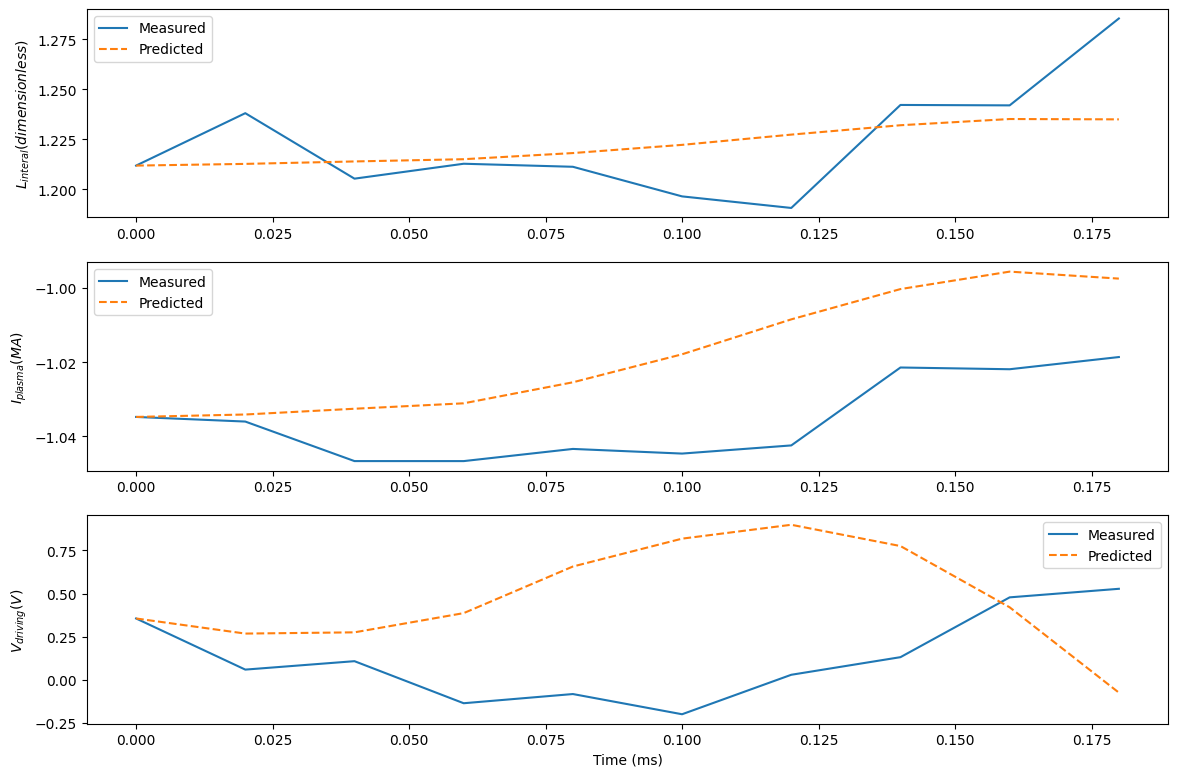

In [28]:
init_state, controls, targets = test_eps[0]
preds = best_model(init_state, controls)

targets_np = np.stack(
    [targets["li"], targets["ip_MA"], targets["vc_minus_vb"]],
    axis=-1
)
preds_np = np.stack(
    [preds["li"], preds["ip_MA"], preds["vc_minus_vb"]],
    axis=-1
)

t = np.array(controls["time"])
t = t - t[0]   # start at 0

labels = ["$L_{interal} (dimensionless)$", "$I_{plasma} (MA)$", "$V_{driving} (V)$"]

plt.figure(figsize=(12, 8))

for i in range(3):
    plt.subplot(3, 1, i + 1)
    plt.plot(t, targets_np[:, i], label="Measured")
    plt.plot(t, preds_np[:, i], "--", label="Predicted")
    plt.ylabel(labels[i])
    plt.legend()

plt.xlabel("Time (ms)")
plt.rcParams.update({'font.size': 14})
plt.tight_layout()
plt.show()

In [29]:
rmse = np.sqrt(np.mean((preds_np - targets_np)**2))
print(f"Root Mean Squared Error (RMSE): {rmse:.6f}")

Root Mean Squared Error (RMSE): 0.340747


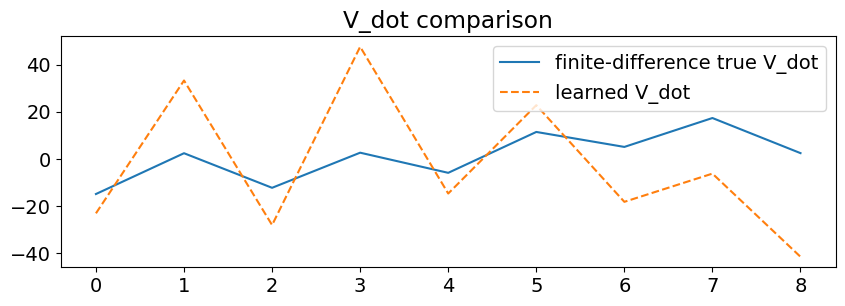

In [30]:
init_state, controls, targets = test_eps[0]
preds = best_model(init_state, controls)

time = controls["time"]
true_vdot = (targets["vc_minus_vb"][1:] - targets["vc_minus_vb"][:-1]) / (time[1:] - time[:-1])

learned_vdot = []
state = init_state

for i in range(len(time) - 1):
    u = {"Vind": controls["Vind"][i]}
    dstate = best_model.dynamics(state, u)
    learned_vdot.append(dstate["vc_minus_vb"])
    state = jax.tree_util.tree_map(
        lambda s, ds: s + (time[i+1] - time[i]) * ds,
        state,
        dstate
    )

learned_vdot = jnp.array(learned_vdot)

plt.figure(figsize=(10, 3))
plt.plot(true_vdot, label="finite-difference true V_dot")
plt.plot(learned_vdot, "--", label="learned V_dot")
plt.legend()
plt.title("V_dot comparison")
plt.show()

In [31]:
def simulate_li_ip_with_true_V(init_state, controls, targets, romero_norm=3.6559,li_scale=11.5,ip_scale=10.0):
    li0 = init_state["li"]
    ip0 = init_state["ip_MA"]

    time = controls["time"]
    Vind = controls["Vind"]
    V_true = targets["vc_minus_vb"]

    def step_fn(state, i):
        li, ip = state
        dt = time[i + 1] - time[i]

        V = V_true[i]
        Vb_minus_Vr = Vind[i]
        Vr_minus_Vb = -Vb_minus_Vr

        li_dot = li_scale * (2 * Vr_minus_Vb - 2 * V) / (romero_norm * ip)
        ip_dot = ip_scale * (2 * Vb_minus_Vr + V) / (romero_norm * li)

        next_state = (
            li + dt * li_dot,
            ip + dt * ip_dot,
        )

        return next_state, next_state

    _, traj = jax.lax.scan(
        step_fn,
        (li0, ip0),
        jnp.arange(len(time) - 1)
    )

    li_traj = jnp.concatenate([li0[None], traj[0]])
    ip_traj = jnp.concatenate([ip0[None], traj[1]])

    return li_traj, ip_traj

In [32]:
li_errors = []
ip_errors = []

for init_state, controls, targets in test_eps:
    preds = best_model(init_state, controls)

    li_err = 100 * jnp.abs(preds["li"][-1] - targets["li"][-1]) / jnp.abs(targets["li"][-1])
    ip_err = 100 * jnp.abs(preds["ip_MA"][-1] - targets["ip_MA"][-1]) / jnp.abs(targets["ip_MA"][-1])

    li_errors.append(float(li_err))
    ip_errors.append(float(ip_err))

print("li mean ± std:", np.mean(li_errors), np.std(li_errors))
print("ip mean ± std:", np.mean(ip_errors), np.std(ip_errors))

li mean ± std: 3.909879073259387 3.4960993443017077
ip mean ± std: 2.596088563434286 1.4313302035956224


In [33]:
print("alpha_ip:", float(best_model.dynamics.alpha_ip))
print("alpha_li:", float(best_model.dynamics.alpha_li))

alpha_ip: 1.9012531042099
alpha_li: 0.4762883186340332


In [34]:
def interp_regular_control(time_old, Vind_old, dt_regular=0.01):
    t0 = time_old[0]
    t1 = time_old[-1]

    time_new = jnp.arange(t0, t1 + 1e-9, dt_regular)

    # linear interpolation onto regular grid
    Vind_new = jnp.interp(time_new, time_old, Vind_old)

    Vind_slope_new = backward_slopes(Vind_new, time_new)

    controls_new = {
        "time": time_new,
        "Vind": Vind_new,
        "Vind_slope": Vind_slope_new,
    }

    return controls_new


def simulate_regular_with_derivatives(model, init_state, controls, dt_regular=0.01):
    controls_reg = interp_regular_control(
        controls["time"],
        controls["Vind"],
        dt_regular=dt_regular,
    )

    preds = model(init_state, controls_reg)

    def deriv_at_state(state, i):
        control_i = {
            "Vind": controls_reg["Vind"][i]
        }
        return model.dynamics(state, control_i)

    derivs = jax.vmap(deriv_at_state)(
        preds,
        jnp.arange(preds["li"].shape[0])
    )

    return controls_reg["time"], preds, derivs

In [35]:
def full_shot_rollout(best_model, df, dt_regular=0.01):
    time_raw = jnp.array(df["time"].values)
    Vind_raw = jnp.array(df["Vind"].values)

    init_state = {
        "li": jnp.array(df["li"].values[0]),
        "ip_MA": jnp.array(df["ip_MA"].values[0]),
        "vc_minus_vb": jnp.array(df["vc_minus_vb"].values[0]),
    }

    controls = {
        "time": time_raw,
        "Vind": Vind_raw,
        "Vind_slope": backward_slopes(Vind_raw, time_raw),
    }

    time_reg, preds_reg, derivs_reg = simulate_regular_with_derivatives(
        best_model,
        init_state,
        controls,
        dt_regular=dt_regular,
    )

    return time_reg, preds_reg, derivs_reg


def compare_full_shot(best_model, df, dt_regular=0.01):
    time_reg, preds_reg, derivs_reg = full_shot_rollout(
        best_model,
        df,
        dt_regular=dt_regular,
    )

    time_raw = jnp.array(df["time"].values)

    targets_reg = {
        "li": jnp.interp(time_reg, time_raw, jnp.array(df["li"].values)),
        "ip_MA": jnp.interp(time_reg, time_raw, jnp.array(df["ip_MA"].values)),
        "vc_minus_vb": jnp.interp(time_reg, time_raw, jnp.array(df["vc_minus_vb"].values)),
    }

    t = np.array(time_reg - time_reg[0])

    labels = {
        "li": "li",
        "ip_MA": "ip_MA",
        "vc_minus_vb": "V",
    }

    plt.figure(figsize=(12, 8))

    for i, key in enumerate(["li", "ip_MA", "vc_minus_vb"]):
        plt.subplot(3, 1, i + 1)
        plt.plot(t, np.array(targets_reg[key]), label=f"Measured {labels[key]}")
        plt.plot(t, np.array(preds_reg[key]), "--", label=f"Predicted {labels[key]}")
        plt.ylabel(labels[key])
        plt.legend()

    plt.xlabel("Time since shot start")
    plt.tight_layout()
    plt.show()

    print("Full-shot metrics:")

    for key in ["li", "ip_MA", "vc_minus_vb"]:
        y_true = targets_reg[key]
        y_pred = preds_reg[key]

        rmse = jnp.sqrt(jnp.mean((y_pred - y_true) ** 2))
        mae = jnp.mean(jnp.abs(y_pred - y_true))
        end_pct = 100 * jnp.abs(y_pred[-1] - y_true[-1]) / (jnp.abs(y_true[-1]) + 1e-8)

        print(
            f"{key}: "
            f"RMSE={float(rmse):.6f}, "
            f"MAE={float(mae):.6f}, "
            f"end % error={float(end_pct):.3f}%"
        )

    return time_reg, preds_reg, targets_reg, derivs_reg

In [36]:
class RomeroAnalytic(eqx.Module):
    romero_norm: float
    kappa: float
    tau: float
    alpha_li: float
    alpha_ip: float

    def __init__(self):
        self.romero_norm = 3.6559
        self.kappa = 0.98
        self.tau = 1.25
        self.alpha_li = 1.0
        self.alpha_ip = 1.0

    def __call__(self, state, control):
        li = state["li"]
        ip = state["ip_MA"]
        V = state["vc_minus_vb"]
        Vind = control["Vind"]

        Vb_minus_Vr = Vind
        Vr_minus_Vb = -Vb_minus_Vr

        li_dot = self.alpha_li * (2 * Vr_minus_Vb - 2 * V) / (self.romero_norm * ip)
        ip_dot = self.alpha_ip * (2 * Vb_minus_Vr + V) / (self.romero_norm * li)

        V_dot = -(V / self.tau) + (self.kappa / self.tau) * Vr_minus_Vb

        return {
            "li": li_dot,
            "ip_MA": ip_dot,
            "vc_minus_vb": V_dot,
        }

In [37]:
romero_model = SimFullObs(RomeroAnalytic())

In [38]:
def compare_full_shot_two_models(model_a, model_b, df, label_a="RomeroNNV", label_b="Analytic Romero", dt_regular=0.01):
    time_a, preds_a, derivs_a = full_shot_rollout(model_a, df, dt_regular)
    time_b, preds_b, derivs_b = full_shot_rollout(model_b, df, dt_regular)

    time_raw = jnp.array(df["time"].values)

    targets = {
        "li": jnp.interp(time_a, time_raw, jnp.array(df["li"].values)),
        "ip_MA": jnp.interp(time_a, time_raw, jnp.array(df["ip_MA"].values)),
        "vc_minus_vb": jnp.interp(time_a, time_raw, jnp.array(df["vc_minus_vb"].values)),
    }

    t = np.array(time_a - time_a[0])

    plt.figure(figsize=(12, 8))

    for i, key in enumerate(["li", "ip_MA", "vc_minus_vb"]):
        plt.subplot(3, 1, i + 1)
        plt.plot(t, np.array(targets[key]), label="Measured")
        plt.plot(t, np.array(preds_a[key]), "--", label=label_a)
        plt.plot(t, np.array(preds_b[key]), ":", label=label_b)
        plt.ylabel(key)
        plt.legend()

    plt.xlabel("Time since shot start")
    plt.tight_layout()
    plt.show()

    for model_label, preds in [(label_a, preds_a), (label_b, preds_b)]:
        print(model_label)

        for key in ["li", "ip_MA", "vc_minus_vb"]:
            y_true = targets[key]
            y_pred = preds[key]

            rmse = jnp.sqrt(jnp.mean((y_pred - y_true) ** 2))
            mae = jnp.mean(jnp.abs(y_pred - y_true))
            end_pct = 100 * jnp.abs(y_pred[-1] - y_true[-1]) / (jnp.abs(y_true[-1]) + 1e-8)

            print(
                f"  {key}: "
                f"RMSE={float(rmse):.6f}, "
                f"MAE={float(mae):.6f}, "
                f"end % error={float(end_pct):.3f}%"
            )

In [39]:
romero_model = SimFullObs(
    RomeroAnalytic()
)

romero_model = eqx.tree_at(
    lambda m: (m.dynamics.alpha_li, m.dynamics.alpha_ip),
    romero_model,
    (float(best_model.dynamics.alpha_li), float(best_model.dynamics.alpha_ip)),
)

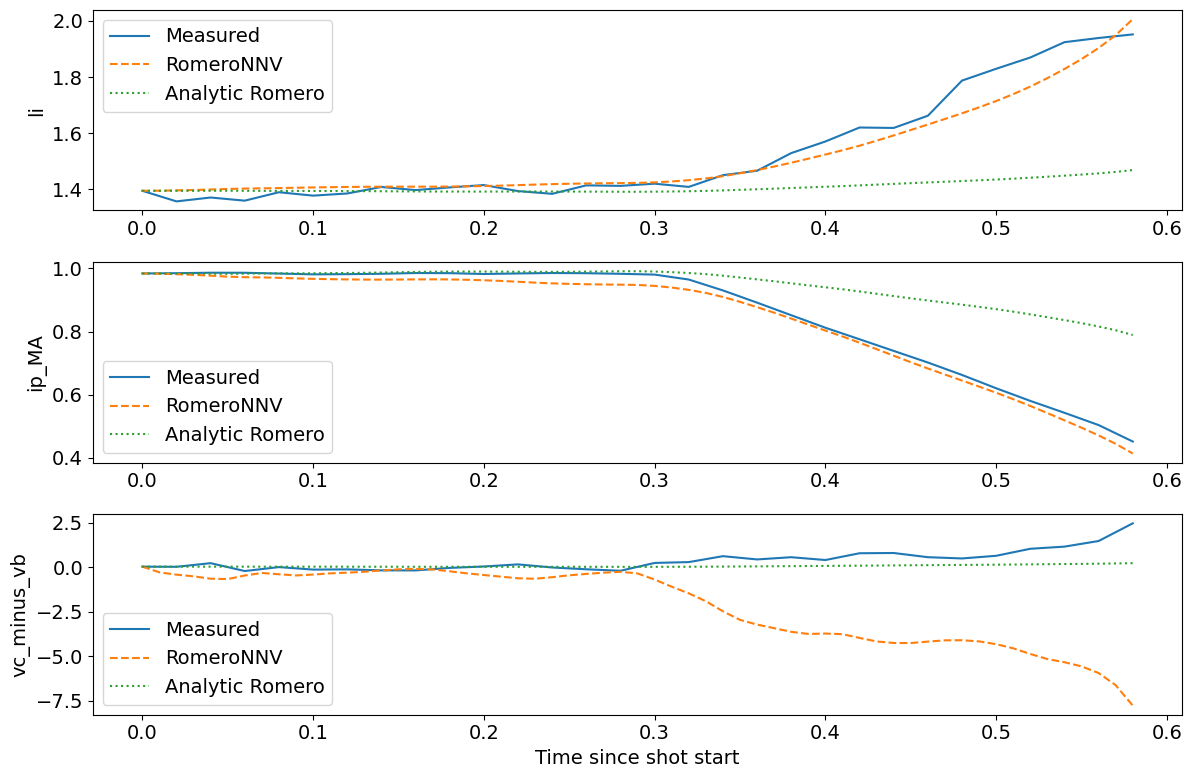

RomeroNNV
  li: RMSE=0.046796, MAE=0.033562, end % error=2.791%
  ip_MA: RMSE=0.021567, MAE=0.019461, end % error=8.378%
  vc_minus_vb: RMSE=3.626138, MAE=2.513198, end % error=415.810%
Analytic Romero
  li: RMSE=0.209167, MAE=0.129573, end % error=24.749%
  ip_MA: RMSE=0.140481, MAE=0.086916, end % error=74.612%
  vc_minus_vb: RMSE=0.573659, MAE=0.385855, end % error=90.896%


In [40]:
compare_full_shot_two_models(
    best_model,
    romero_model,
    df_list[0],
)

In [41]:
def endpoint_percent_errors(model, eps, name="set"):
    li_errors = []
    ip_errors = []

    for init_state, controls, targets in eps:
        preds = model(init_state, controls)

        li_err = 100 * jnp.abs(preds["li"][-1] - targets["li"][-1]) / (jnp.abs(targets["li"][-1]) + 1e-8)
        ip_err = 100 * jnp.abs(preds["ip_MA"][-1] - targets["ip_MA"][-1]) / (jnp.abs(targets["ip_MA"][-1]) + 1e-8)

        li_errors.append(float(li_err))
        ip_errors.append(float(ip_err))

    print(f"{name} li mean ± std:", np.mean(li_errors), np.std(li_errors))
    print(f"{name} ip mean ± std:", np.mean(ip_errors), np.std(ip_errors))

In [42]:
endpoint_percent_errors(best_model, train_eps, "Train")
endpoint_percent_errors(best_model, val_eps, "Validation")
endpoint_percent_errors(best_model, test_eps, "Test")

Train li mean ± std: 3.98020910350535 3.8592878027979673
Train ip mean ± std: 2.5800201996000456 1.5463434263091211
Validation li mean ± std: 4.207609272496716 3.5042380015606396
Validation ip mean ± std: 2.8170390214865946 1.568641553474733
Test li mean ± std: 3.909879073259387 3.4960993443017077
Test ip mean ± std: 2.596088563434286 1.4313302035956224


In [77]:
li_errors = []
ip_errors = []

for init_state, controls, targets in test_eps:
    preds = romero_model(init_state, controls)

    li_err = 100 * jnp.abs(preds["li"][-1] - targets["li"][-1]) / jnp.abs(targets["li"][-1])
    ip_err = 100 * jnp.abs(preds["ip_MA"][-1] - targets["ip_MA"][-1]) / jnp.abs(targets["ip_MA"][-1])

    li_errors.append(float(li_err))
    ip_errors.append(float(ip_err))

print("Analytic Romero li mean ± std:", np.mean(li_errors), np.std(li_errors))
print("Analytic Romero ip mean ± std:", np.mean(ip_errors), np.std(ip_errors))

Analytic Romero li mean ± std: 6.032898416720241 5.364290101715023
Analytic Romero ip mean ± std: 9.524867954069233 13.754251228013672


In [75]:
endpoint_percent_errors_for_model(romero_model, train_eps, "Analytic Romero Train")
endpoint_percent_errors_for_model(romero_model, val_eps, "Analytic Romero Validation")
endpoint_percent_errors_for_model(romero_model, test_eps, "Analytic Romero Test")

Analytic Romero Train li mean ± std: 6.090223287522797 5.396051125632133
Analytic Romero Train ip mean ± std: 9.26327269520209 13.153707992706703
Analytic Romero Validation li mean ± std: 6.589913836377821 5.376511313680989
Analytic Romero Validation ip mean ± std: 8.805592618415512 11.377638788130023
Analytic Romero Test li mean ± std: 6.032898416720241 5.364290101715023
Analytic Romero Test ip mean ± std: 9.524867954069233 13.754251228013672


In [76]:
endpoint_percent_errors_for_model(best_model, test_eps, "RomeroNNV Test")
endpoint_percent_errors_for_model(romero_model, test_eps, "Analytic Romero Test")

RomeroNNV Test li mean ± std: 3.909879073259387 3.4960993443017077
RomeroNNV Test ip mean ± std: 2.596088563434286 1.4313302035956224
Analytic Romero Test li mean ± std: 6.032898416720241 5.364290101715023
Analytic Romero Test ip mean ± std: 9.524867954069233 13.754251228013672


In [43]:
def plot_V_for_training_shots(train_dfs, max_shots=None):
    dfs_to_plot = train_dfs if max_shots is None else train_dfs[:max_shots]

    plt.figure(figsize=(12, 6))

    for df in dfs_to_plot:
        t = np.array(df["time"].values)
        t = t - t[0]

        V = np.array(df["vc_minus_vb"].values)

        plt.plot(t, V, alpha=0.25)

    plt.xlabel("Time since shot start")
    plt.ylabel("V = vc_minus_vb")
    plt.title(f"V time series for training shots, n={len(dfs_to_plot)}")
    plt.tight_layout()
    plt.show()

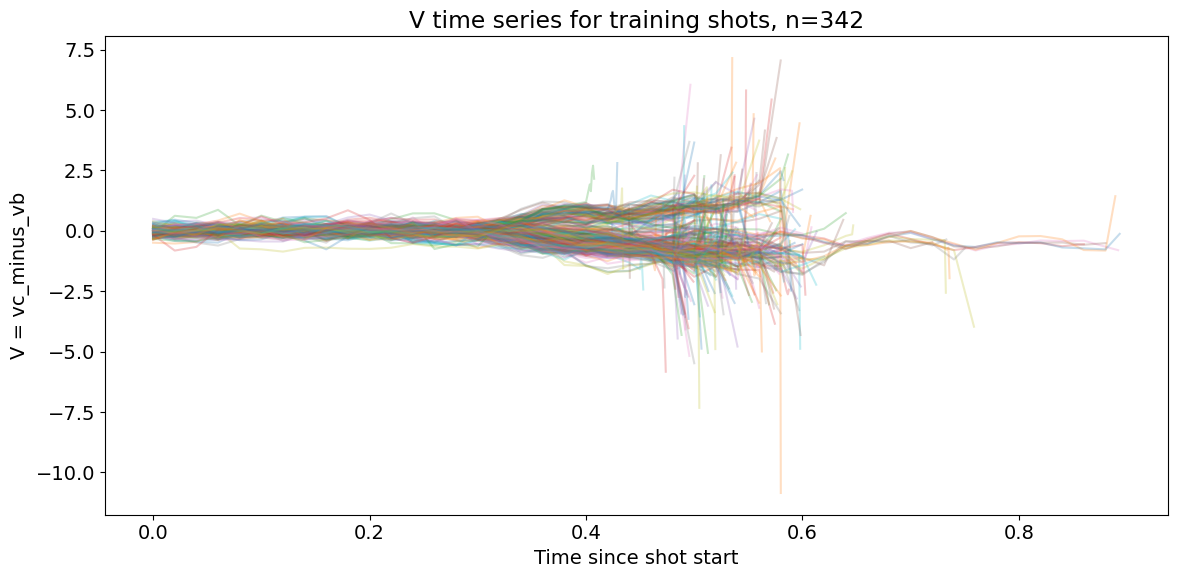

In [44]:
plot_V_for_training_shots(train_dfs)

In [45]:
def plot_V_normalized_time(train_dfs, max_shots=None):
    dfs_to_plot = train_dfs if max_shots is None else train_dfs[:max_shots]

    plt.figure(figsize=(12, 6))

    for df in dfs_to_plot:

        V = np.array(df["vc_minus_vb"].values)

        # normalized time axis
        t_norm = np.linspace(0, 1, len(V))

        plt.plot(t_norm, V, alpha=0.25)

    plt.xlabel("Normalized shot time")
    plt.ylabel("V = vc_minus_vb")
    plt.title(f"Normalized V trajectories, n={len(dfs_to_plot)}")
    plt.tight_layout()
    plt.show()

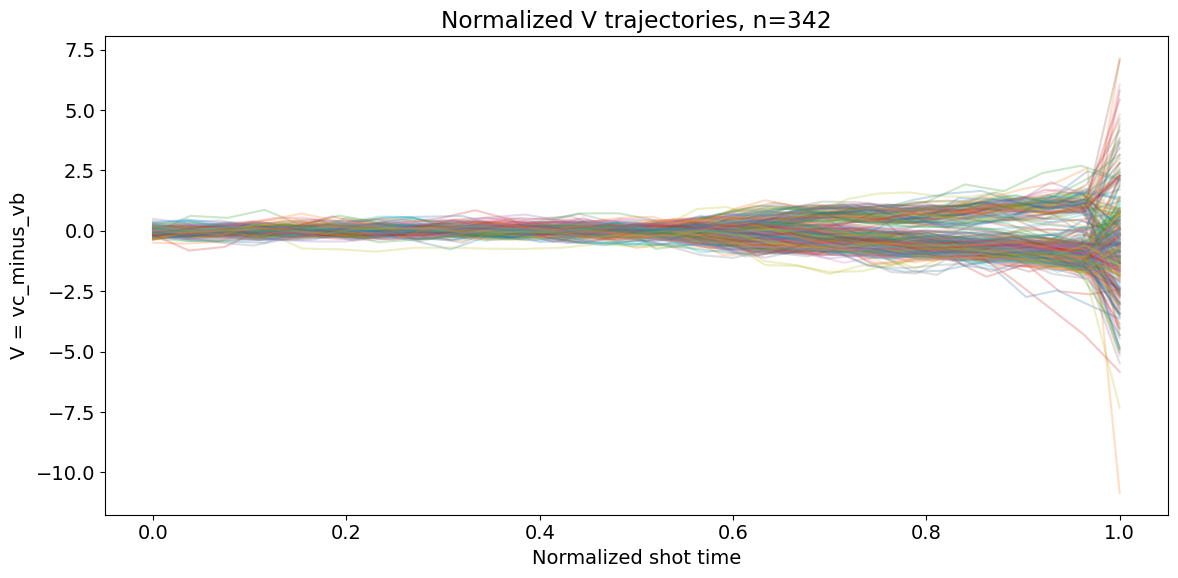

In [46]:
plot_V_normalized_time(train_dfs)

# Interpolate measured V and analytic V onto a common normalized grid

In [47]:
def rollout_model_full_shot(model, df):
    time_raw = jnp.array(df["time"].values)
    Vind_raw = jnp.array(df["Vind"].values)

    init_state = {
        "li": jnp.array(df["li"].values[0]),
        "ip_MA": jnp.array(df["ip_MA"].values[0]),
        "vc_minus_vb": jnp.array(df["vc_minus_vb"].values[0]),
    }

    controls = {
        "time": time_raw,
        "Vind": Vind_raw,
        "Vind_slope": backward_slopes(Vind_raw, time_raw),
    }

    preds = model(init_state, controls)
    return time_raw, preds

In [48]:
def collect_V_comparison_over_shots(dfs, analytic_model, n_grid=200):
    tau_grid = jnp.linspace(0.0, 1.0, n_grid)

    measured_V_all = []
    analytic_V_all = []

    for df in dfs:
        time_raw = jnp.array(df["time"].values)
        t_norm_raw = (time_raw - time_raw[0]) / (time_raw[-1] - time_raw[0])

        V_measured = jnp.array(df["vc_minus_vb"].values)

        _, preds_analytic = rollout_model_full_shot(analytic_model, df)
        V_analytic = preds_analytic["vc_minus_vb"]

        V_measured_grid = jnp.interp(tau_grid, t_norm_raw, V_measured)
        V_analytic_grid = jnp.interp(tau_grid, t_norm_raw, V_analytic)

        measured_V_all.append(V_measured_grid)
        analytic_V_all.append(V_analytic_grid)

    measured_V_all = jnp.stack(measured_V_all)
    analytic_V_all = jnp.stack(analytic_V_all)

    return tau_grid, measured_V_all, analytic_V_all

In [49]:
def plot_V_mean_std_comparison(dfs, analytic_model, n_grid=200, title="Training shots"):
    tau_grid, measured_V, analytic_V = collect_V_comparison_over_shots(
        dfs,
        analytic_model,
        n_grid=n_grid,
    )

    measured_mean = jnp.mean(measured_V, axis=0)
    measured_std  = jnp.std(measured_V, axis=0)

    analytic_mean = jnp.mean(analytic_V, axis=0)
    analytic_std  = jnp.std(analytic_V, axis=0)

    tau = np.array(tau_grid)

    plt.figure(figsize=(12, 6))

    plt.plot(tau, np.array(measured_mean), label="Measured V mean")
    plt.fill_between(
        tau,
        np.array(measured_mean - measured_std),
        np.array(measured_mean + measured_std),
        alpha=0.2,
        label="Measured V ±1 std",
    )

    plt.plot(tau, np.array(analytic_mean), "--", label="Analytic Romero V mean")
    plt.fill_between(
        tau,
        np.array(analytic_mean - analytic_std),
        np.array(analytic_mean + analytic_std),
        alpha=0.2,
        label="Analytic Romero V ±1 std",
    )

    plt.xlabel("Normalized shot time")
    plt.ylabel("V = vc_minus_vb")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

    rmse = jnp.sqrt(jnp.mean((analytic_V - measured_V) ** 2))
    mae = jnp.mean(jnp.abs(analytic_V - measured_V))

    print(f"{title} analytic V RMSE: {float(rmse):.6f}")
    print(f"{title} analytic V MAE:  {float(mae):.6f}")

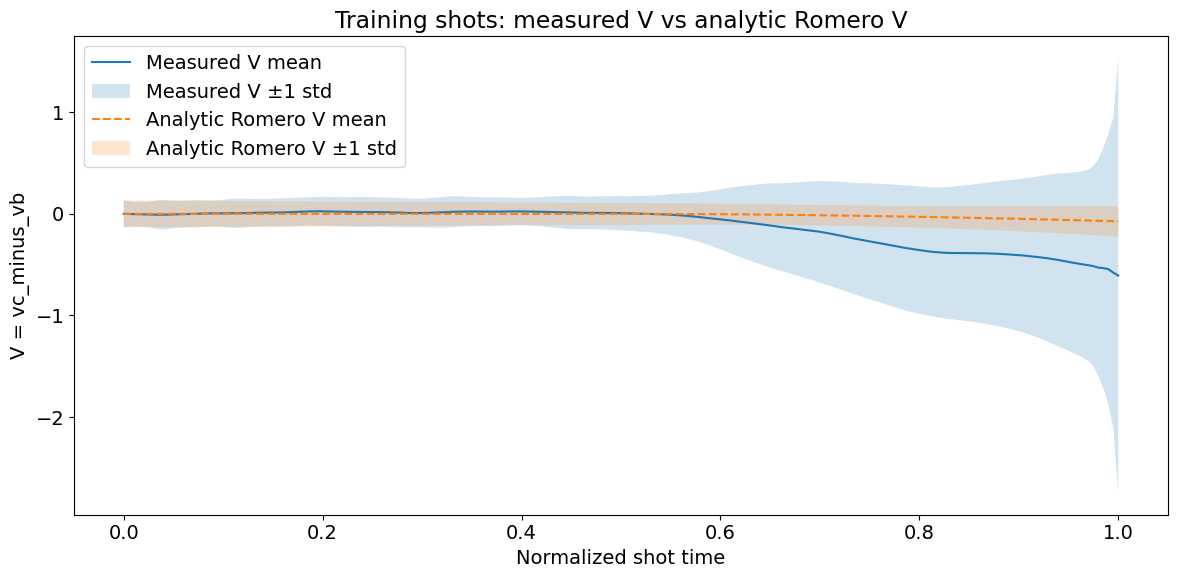

Training shots: measured V vs analytic Romero V analytic V RMSE: 0.491116
Training shots: measured V vs analytic Romero V analytic V MAE:  0.324772


In [50]:
plot_V_mean_std_comparison(
    train_dfs,
    romero_model,
    n_grid=200,
    title="Training shots: measured V vs analytic Romero V",
)

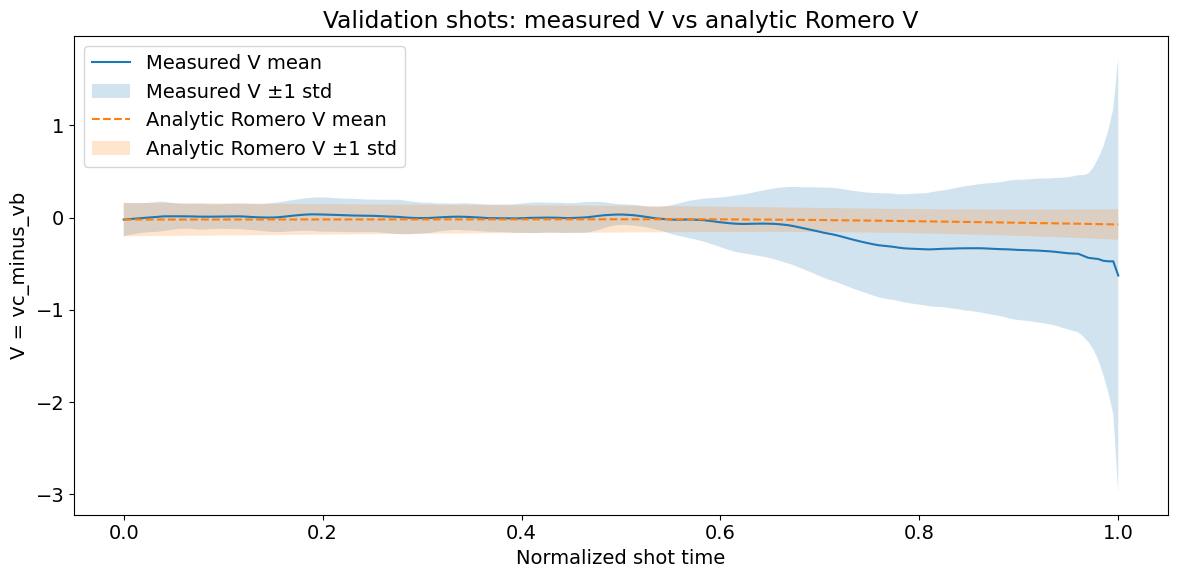

Validation shots: measured V vs analytic Romero V analytic V RMSE: 0.494479
Validation shots: measured V vs analytic Romero V analytic V MAE:  0.327349


In [51]:
plot_V_mean_std_comparison(
    val_dfs,
    romero_model,
    n_grid=200,
    title="Validation shots: measured V vs analytic Romero V",
)

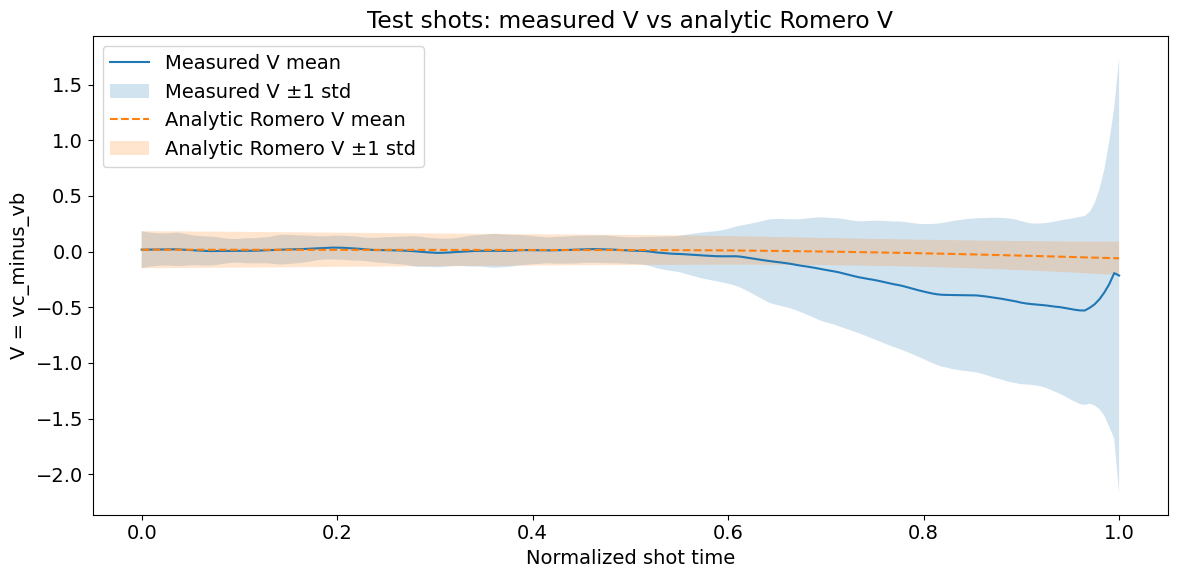

Test shots: measured V vs analytic Romero V analytic V RMSE: 0.482438
Test shots: measured V vs analytic Romero V analytic V MAE:  0.319384


In [52]:
plot_V_mean_std_comparison(
    test_dfs,
    romero_model,
    n_grid=200,
    title="Test shots: measured V vs analytic Romero V",
)

In [53]:
def collect_model_vs_measured_over_shots(dfs, model, signal_key, n_grid=200):
    tau_grid = jnp.linspace(0.0, 1.0, n_grid)

    measured_all = []
    predicted_all = []

    for df in dfs:
        time_raw = jnp.array(df["time"].values)
        t_norm_raw = (time_raw - time_raw[0]) / (time_raw[-1] - time_raw[0])

        # measured signal
        measured = jnp.array(df[signal_key].values)

        # model rollout over full shot
        time_model, preds_model, _ = full_shot_rollout(
            model,
            df,
            dt_regular=0.01,
        )

        t_norm_model = (time_model - time_model[0]) / (time_model[-1] - time_model[0])

        measured_grid = jnp.interp(tau_grid, t_norm_raw, measured)
        predicted_grid = jnp.interp(tau_grid, t_norm_model, preds_model[signal_key])

        measured_all.append(measured_grid)
        predicted_all.append(predicted_grid)

    return tau_grid, jnp.stack(measured_all), jnp.stack(predicted_all)

In [54]:
def plot_ode_results_li_ip(dfs, model, title="Training shots", n_grid=200):
    tau_grid, li_meas, li_pred = collect_model_vs_measured_over_shots(
        dfs, model, "li", n_grid=n_grid
    )
    _, ip_meas, ip_pred = collect_model_vs_measured_over_shots(
        dfs, model, "ip_MA", n_grid=n_grid
    )

    tau = np.array(tau_grid)

    plt.figure(figsize=(12, 8))

    for i, (name, measured, predicted) in enumerate([
        ("li", li_meas, li_pred),
        ("ip_MA", ip_meas, ip_pred),
    ]):
        meas_mean = jnp.mean(measured, axis=0)
        meas_std = jnp.std(measured, axis=0)

        pred_mean = jnp.mean(predicted, axis=0)
        pred_std = jnp.std(predicted, axis=0)

        plt.subplot(2, 1, i + 1)

        plt.plot(tau, np.array(meas_mean), label=f"Measured {name} mean")
        plt.fill_between(
            tau,
            np.array(meas_mean - meas_std),
            np.array(meas_mean + meas_std),
            alpha=0.2,
            label=f"Measured {name} ±1 std",
        )

        plt.plot(tau, np.array(pred_mean), "--", label=f"ODE predicted {name} mean")
        plt.fill_between(
            tau,
            np.array(pred_mean - pred_std),
            np.array(pred_mean + pred_std),
            alpha=0.2,
            label=f"ODE predicted {name} ±1 std",
        )

        plt.ylabel(name)
        plt.legend()

    plt.xlabel("Normalized shot time")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

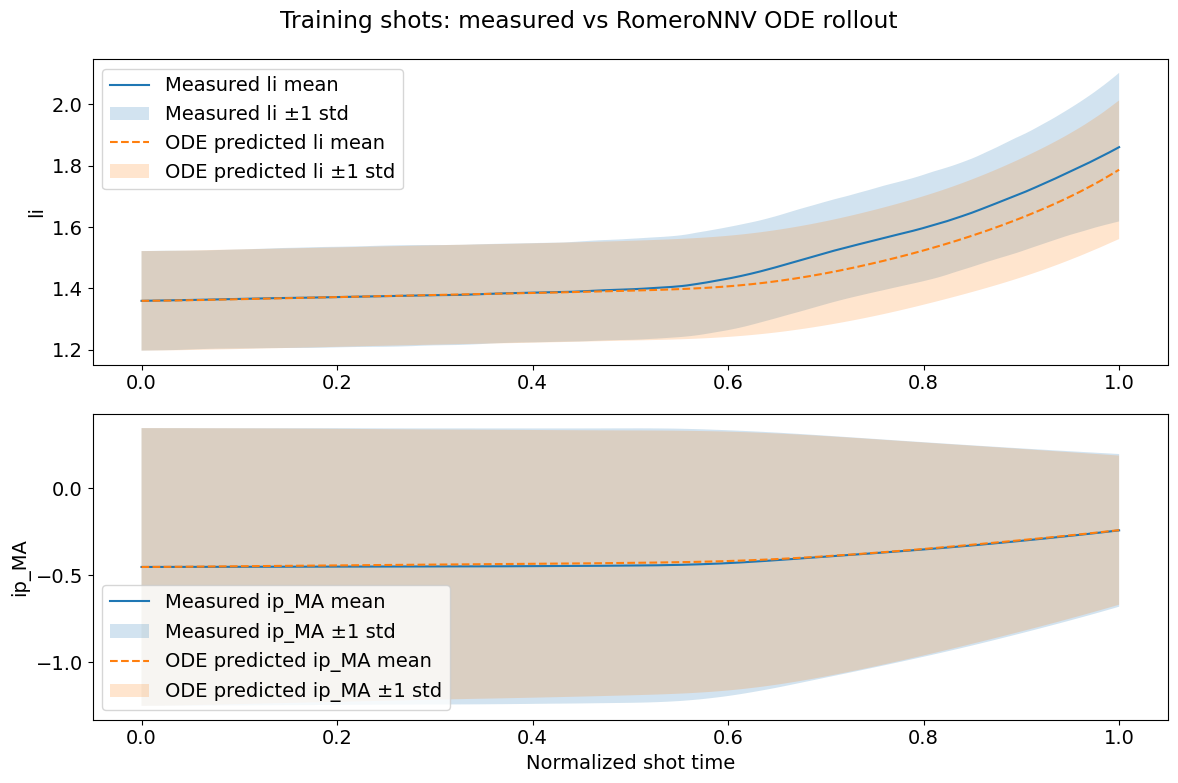

In [55]:
plot_ode_results_li_ip(
    train_dfs,
    best_model,
    title="Training shots: measured vs RomeroNNV ODE rollout",
)

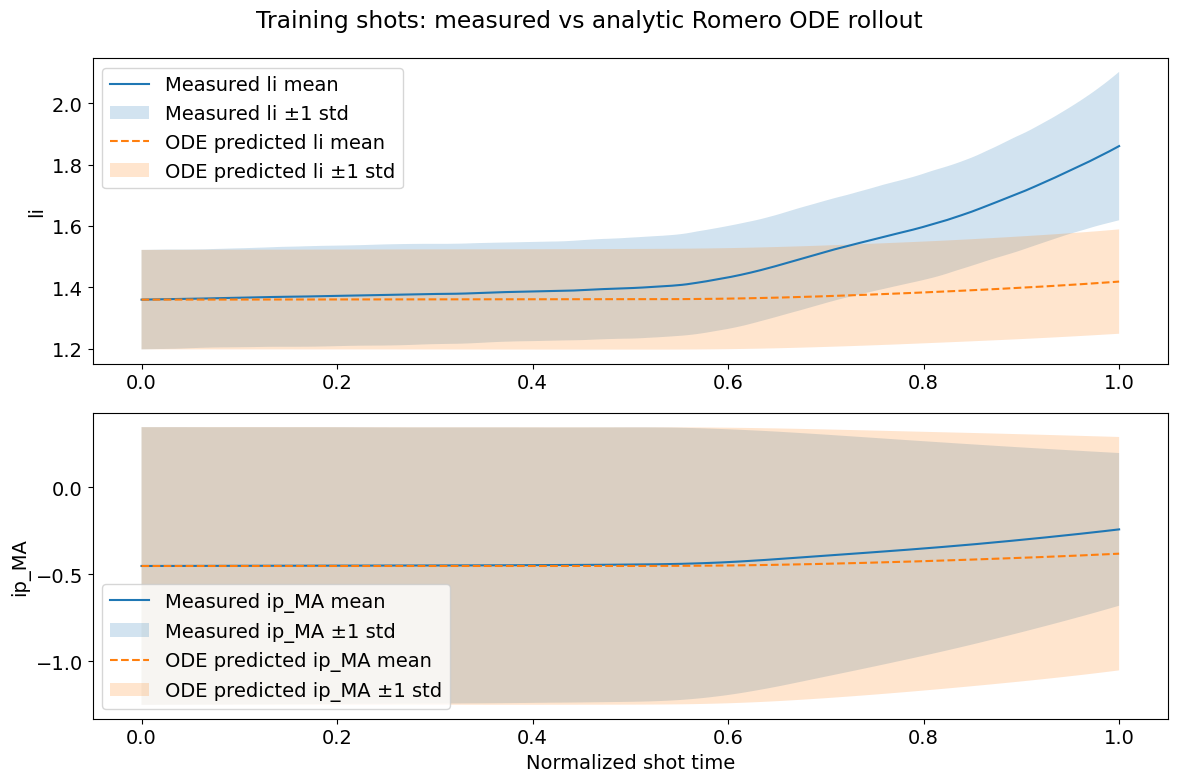

In [56]:
plot_ode_results_li_ip(
    train_dfs,
    romero_model,
    title="Training shots: measured vs analytic Romero ODE rollout",
)

In [57]:
def collect_two_model_comparison(dfs, model_a, model_b, signal_key, n_grid=200):
    tau_grid = jnp.linspace(0.0, 1.0, n_grid)

    measured_all = []
    pred_a_all = []
    pred_b_all = []

    for df in dfs:
        time_raw = jnp.array(df["time"].values)
        t_norm_raw = (time_raw - time_raw[0]) / (time_raw[-1] - time_raw[0])

        measured = jnp.array(df[signal_key].values)

        time_a, preds_a, _ = full_shot_rollout(model_a, df, dt_regular=0.01)
        time_b, preds_b, _ = full_shot_rollout(model_b, df, dt_regular=0.01)

        t_norm_a = (time_a - time_a[0]) / (time_a[-1] - time_a[0])
        t_norm_b = (time_b - time_b[0]) / (time_b[-1] - time_b[0])

        measured_all.append(jnp.interp(tau_grid, t_norm_raw, measured))
        pred_a_all.append(jnp.interp(tau_grid, t_norm_a, preds_a[signal_key]))
        pred_b_all.append(jnp.interp(tau_grid, t_norm_b, preds_b[signal_key]))

    return (
        tau_grid,
        jnp.stack(measured_all),
        jnp.stack(pred_a_all),
        jnp.stack(pred_b_all),
    )


def plot_li_ip_three_way(
    dfs,
    romero_nnv_model,
    analytic_romero_model,
    title="Training shots",
    n_grid=200,
):
    for signal_key, ylabel in [
        ("li", "li"),
        ("ip_MA", "ip_MA"),
    ]:
        tau, measured, nnv, analytic = collect_two_model_comparison(
            dfs,
            romero_nnv_model,
            analytic_romero_model,
            signal_key,
            n_grid=n_grid,
        )

        tau_np = np.array(tau)

        measured_mean = jnp.mean(measured, axis=0)
        nnv_mean = jnp.mean(nnv, axis=0)
        analytic_mean = jnp.mean(analytic, axis=0)

        measured_std = jnp.std(measured, axis=0)
        nnv_std = jnp.std(nnv, axis=0)
        analytic_std = jnp.std(analytic, axis=0)

        plt.figure(figsize=(12, 5))

        plt.plot(tau_np, np.array(measured_mean), label=f"Measured {ylabel} mean")
        plt.fill_between(
            tau_np,
            np.array(measured_mean - measured_std),
            np.array(measured_mean + measured_std),
            alpha=0.15,
        )

        plt.plot(tau_np, np.array(nnv_mean), "--", label=f"RomeroNNV {ylabel} mean")
        plt.fill_between(
            tau_np,
            np.array(nnv_mean - nnv_std),
            np.array(nnv_mean + nnv_std),
            alpha=0.15,
        )

        plt.plot(tau_np, np.array(analytic_mean), ":", label=f"Analytic Romero {ylabel} mean")
        plt.fill_between(
            tau_np,
            np.array(analytic_mean - analytic_std),
            np.array(analytic_mean + analytic_std),
            alpha=0.15,
        )

        plt.xlabel("Normalized shot time")
        plt.ylabel(ylabel)
        plt.title(f"{title}: {ylabel} measured vs RomeroNNV vs analytic Romero")
        plt.legend()
        plt.tight_layout()
        plt.show()

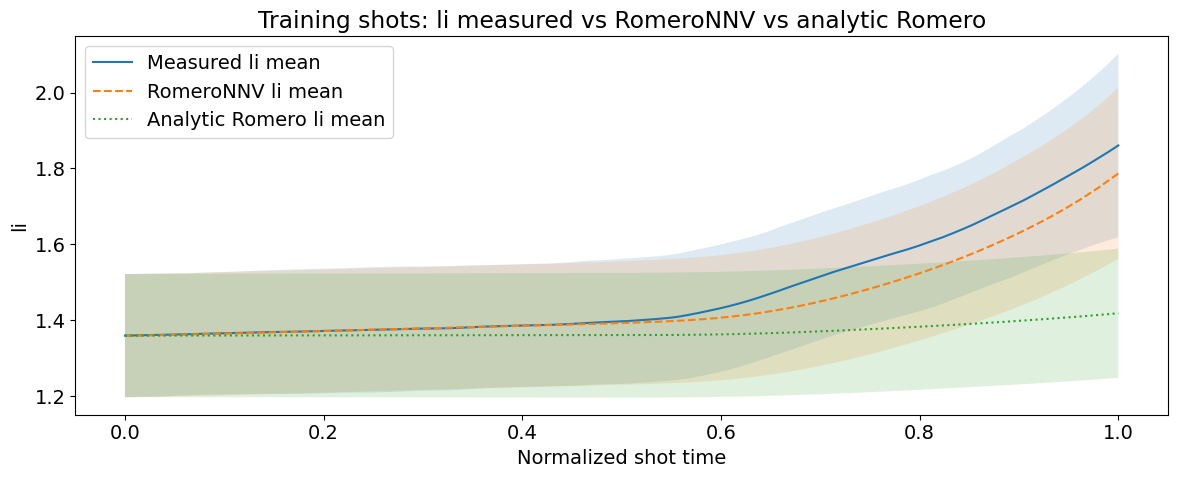

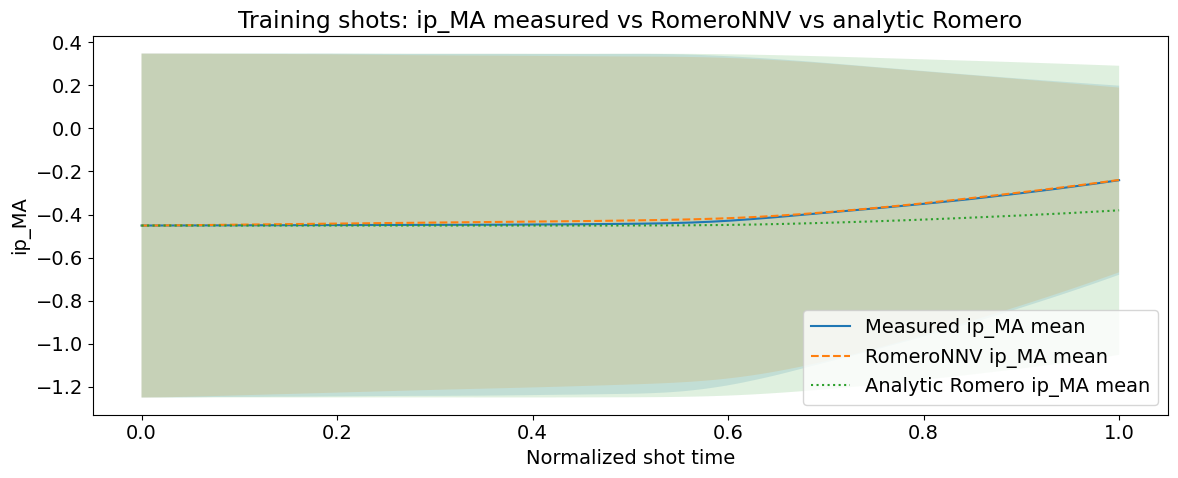

In [58]:
plot_li_ip_three_way(
    train_dfs,
    best_model,
    romero_model,
    title="Training shots",
)

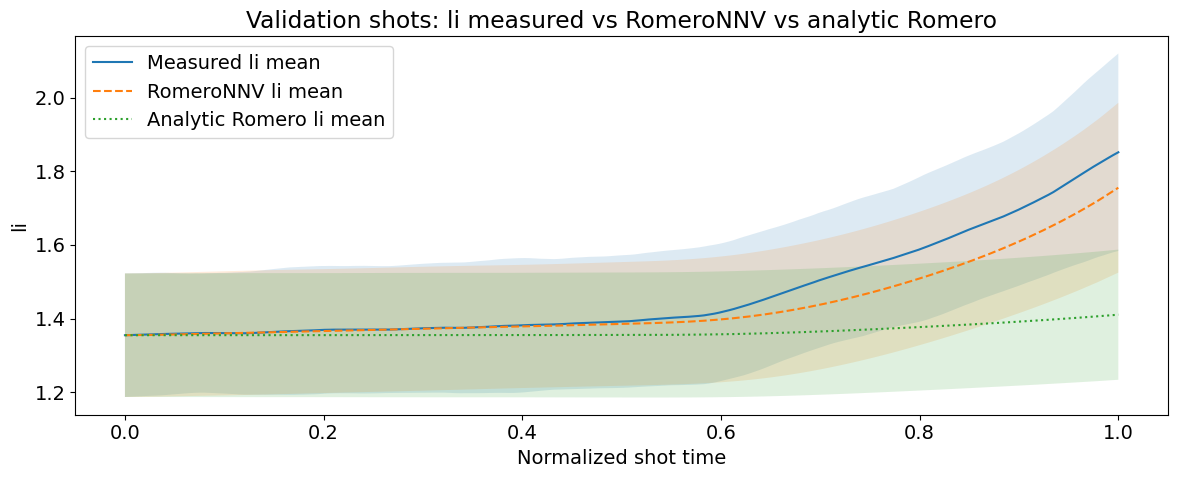

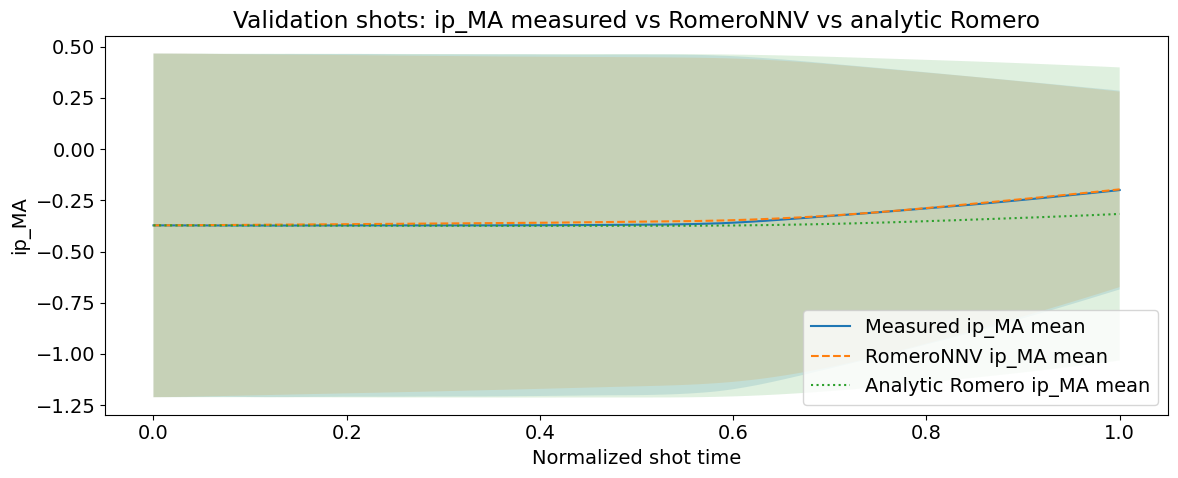

In [59]:
plot_li_ip_three_way(val_dfs, best_model, romero_model, title="Validation shots")

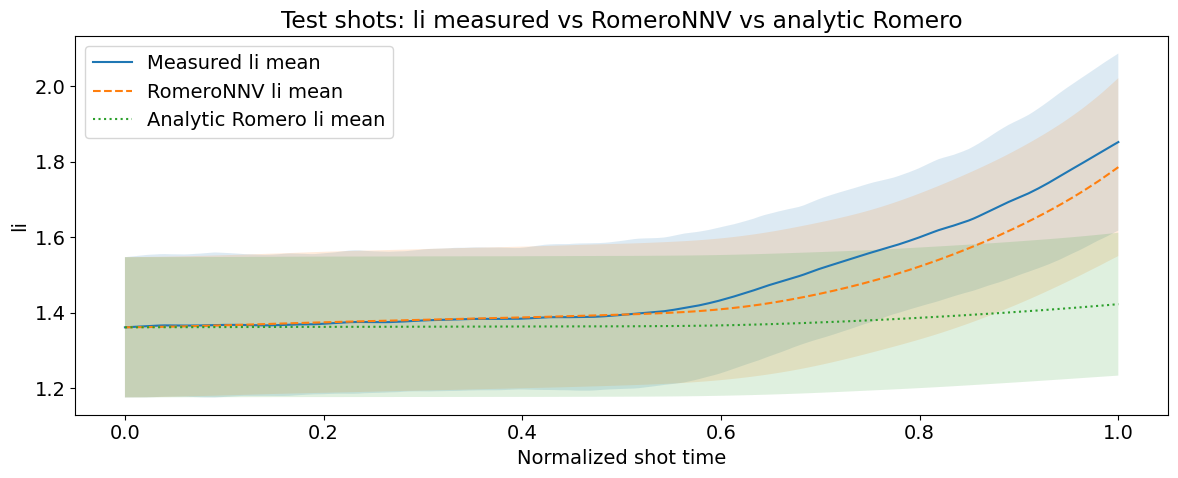

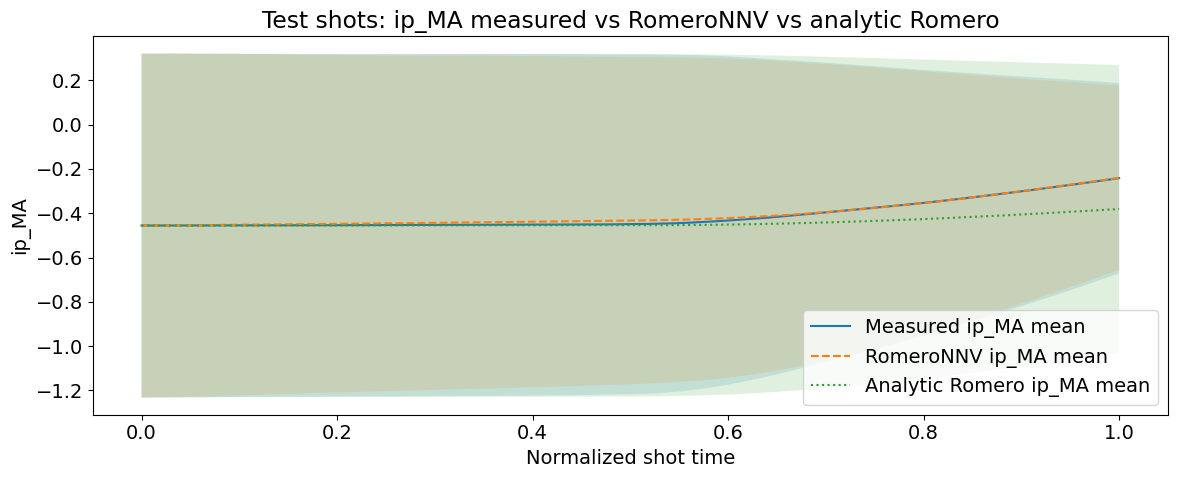

In [60]:
plot_li_ip_three_way(test_dfs, best_model, romero_model, title="Test shots")

In [61]:
def compute_vdot_residual_for_df(df, romero_model, dt_regular=0.01):
    time_raw = jnp.array(df["time"].values)

    time_reg = jnp.arange(time_raw[0], time_raw[-1], dt_regular)

    li = jnp.interp(time_reg, time_raw, jnp.array(df["li"].values))
    ip = jnp.interp(time_reg, time_raw, jnp.array(df["ip_MA"].values))
    V = jnp.interp(time_reg, time_raw, jnp.array(df["vc_minus_vb"].values))
    Vind = jnp.interp(time_reg, time_raw, jnp.array(df["Vind"].values))

    # measured derivative of V
    V_dot_true = (V[1:] - V[:-1]) / dt_regular

    # analytic Romero V_dot evaluated on measured state
    V_dot_romero = []

    for k in range(len(time_reg) - 1):
        state = {
            "li": li[k],
            "ip_MA": ip[k],
            "vc_minus_vb": V[k],
        }
        control = {
            "Vind": Vind[k],
        }

        dstate = romero_model.dynamics(state, control)
        V_dot_romero.append(dstate["vc_minus_vb"])

    V_dot_romero = jnp.array(V_dot_romero)

    residual = V_dot_true - V_dot_romero

    X = {
        "time": time_reg[:-1],
        "li": li[:-1],
        "ip_MA": ip[:-1],
        "V": V[:-1],
        "Vind": Vind[:-1],
        "V_dot_true": V_dot_true,
        "V_dot_romero": V_dot_romero,
        "residual": residual,
    }

    return X

In [62]:
def collect_residual_dataset(dfs, romero_model, dt_regular=0.01, max_shots=None):
    dfs_to_use = dfs if max_shots is None else dfs[:max_shots]

    rows = []

    for df in dfs_to_use:
        X = compute_vdot_residual_for_df(df, romero_model, dt_regular)

        n = len(X["residual"])

        for k in range(n):
            rows.append([
                float(X["li"][k]),
                float(X["ip_MA"][k]),
                float(X["V"][k]),
                float(X["Vind"][k]),
                float(X["V_dot_true"][k]),
                float(X["V_dot_romero"][k]),
                float(X["residual"][k]),
            ])

    columns = ["li", "ip_MA", "V", "Vind", "V_dot_true", "V_dot_romero", "residual"]
    return pd.DataFrame(rows, columns=columns)

In [63]:
resid_df = collect_residual_dataset(
    train_dfs,
    romero_model,
    dt_regular=0.01,
    max_shots=50,
)

In [64]:
def plot_residual_diagnostics(resid_df):
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))

    axes = axes.ravel()

    pairs = [
        ("V_dot_romero", "residual"),
        ("V", "residual"),
        ("Vind", "residual"),
        ("li", "residual"),
        ("ip_MA", "residual"),
        ("V_dot_true", "V_dot_romero"),
    ]

    for ax, (xkey, ykey) in zip(axes, pairs):
        ax.scatter(
            resid_df[xkey],
            resid_df[ykey],
            s=6,
            alpha=0.2,
        )
        ax.set_xlabel(xkey)
        ax.set_ylabel(ykey)

    plt.suptitle("Analytic Romero V_dot residual structure")
    plt.tight_layout()
    plt.show()

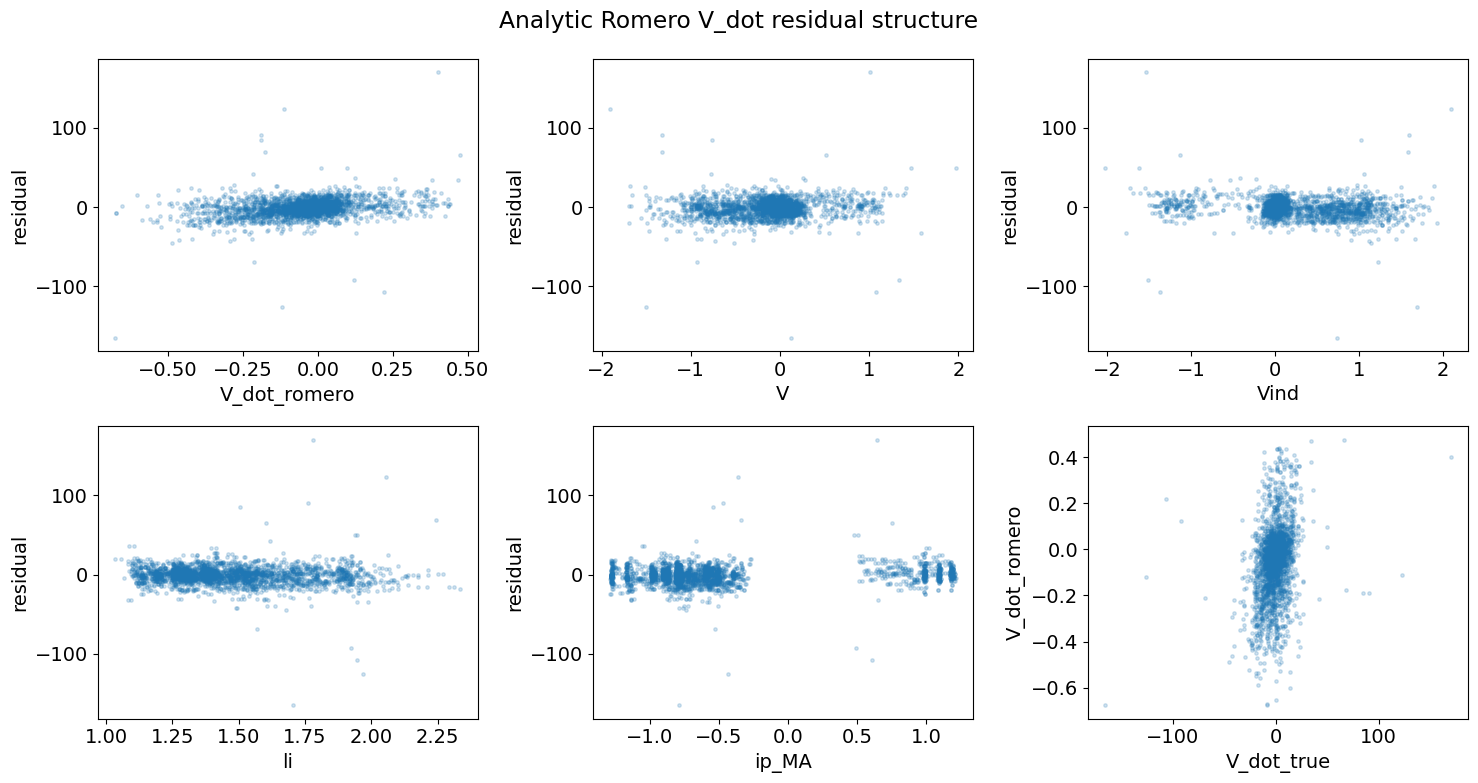

In [65]:
plot_residual_diagnostics(resid_df)

In [66]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def plot_residual_library_pca(resid_df):
    li = resid_df["li"].values
    ip = resid_df["ip_MA"].values
    V = resid_df["V"].values
    Vind = resid_df["Vind"].values

    # simple candidate SINDy library
    Theta = np.column_stack([
        V,
        Vind,
        li,
        ip,
        V**2,
        Vind**2,
        li**2,
        ip**2,
        V * Vind,
        li * V,
        ip * V,
        li * Vind,
        ip * Vind,
    ])

    Theta_scaled = StandardScaler().fit_transform(Theta)

    pca = PCA()
    pca.fit(Theta_scaled)

    explained = np.cumsum(pca.explained_variance_ratio_)

    plt.figure(figsize=(8, 4))
    plt.plot(np.arange(1, len(explained) + 1), explained, marker="o")
    plt.xlabel("Number of PCA components")
    plt.ylabel("Cumulative explained variance")
    plt.title("Low-dimensional structure in SINDy candidate library")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print("Explained variance first 3 components:", explained[:3])
    print("Explained variance first 5 components:", explained[:5])

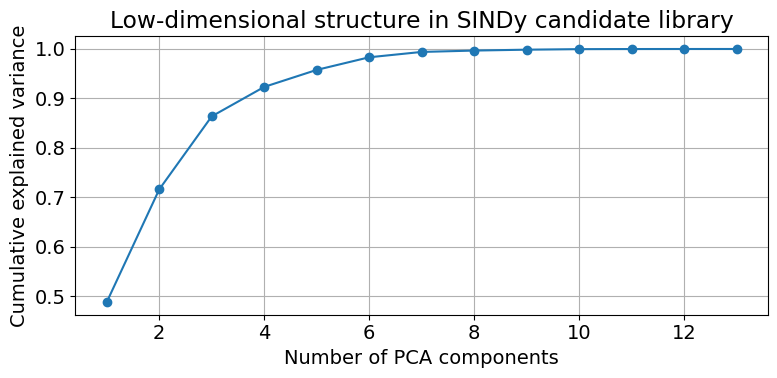

Explained variance first 3 components: [0.48872812 0.71639428 0.86392321]
Explained variance first 5 components: [0.48872812 0.71639428 0.86392321 0.92336671 0.95773991]


In [67]:
plot_residual_library_pca(resid_df)

# Let's look at the last 40% of the shots

In [68]:
#lets add a normlized time filter to keep the last half of each shot
def compute_vdot_residual_for_df_late(
    df,
    romero_model,
    dt_regular=0.01,
    tau_min=0.5,
):
    time_raw = jnp.array(df["time"].values)

    time_reg = jnp.arange(time_raw[0], time_raw[-1], dt_regular)
    tau_reg = (time_reg - time_reg[0]) / (time_reg[-1] - time_reg[0])

    li = jnp.interp(time_reg, time_raw, jnp.array(df["li"].values))
    ip = jnp.interp(time_reg, time_raw, jnp.array(df["ip_MA"].values))
    V = jnp.interp(time_reg, time_raw, jnp.array(df["vc_minus_vb"].values))
    Vind = jnp.interp(time_reg, time_raw, jnp.array(df["Vind"].values))

    V_dot_true = (V[1:] - V[:-1]) / dt_regular

    V_dot_romero = []

    for k in range(len(time_reg) - 1):
        state = {
            "li": li[k],
            "ip_MA": ip[k],
            "vc_minus_vb": V[k],
        }
        control = {"Vind": Vind[k]}

        dstate = romero_model.dynamics(state, control)
        V_dot_romero.append(dstate["vc_minus_vb"])

    V_dot_romero = jnp.array(V_dot_romero)
    residual = V_dot_true - V_dot_romero

    tau_mid = tau_reg[:-1]

    mask = tau_mid >= tau_min

    return {
        "tau": tau_mid[mask],
        "li": li[:-1][mask],
        "ip_MA": ip[:-1][mask],
        "V": V[:-1][mask],
        "Vind": Vind[:-1][mask],
        "V_dot_true": V_dot_true[mask],
        "V_dot_romero": V_dot_romero[mask],
        "residual": residual[mask],
    }

In [69]:
def collect_late_residual_dataset(
    dfs,
    romero_model,
    dt_regular=0.01,
    tau_min=0.5,
    max_shots=None,
):
    dfs_to_use = dfs if max_shots is None else dfs[:max_shots]
    rows = []

    for df in dfs_to_use:
        X = compute_vdot_residual_for_df_late(
            df,
            romero_model,
            dt_regular=dt_regular,
            tau_min=tau_min,
        )

        n = len(X["residual"])

        for k in range(n):
            rows.append([
                float(X["tau"][k]),
                float(X["li"][k]),
                float(X["ip_MA"][k]),
                float(X["V"][k]),
                float(X["Vind"][k]),
                float(X["V_dot_true"][k]),
                float(X["V_dot_romero"][k]),
                float(X["residual"][k]),
            ])

    columns = [
        "tau",
        "li",
        "ip_MA",
        "V",
        "Vind",
        "V_dot_true",
        "V_dot_romero",
        "residual",
    ]

    return pd.DataFrame(rows, columns=columns)

In [70]:
late_resid_df = collect_late_residual_dataset(
    train_dfs,
    romero_model,
    dt_regular=0.01,
    tau_min=0.5,
    max_shots=50,
)

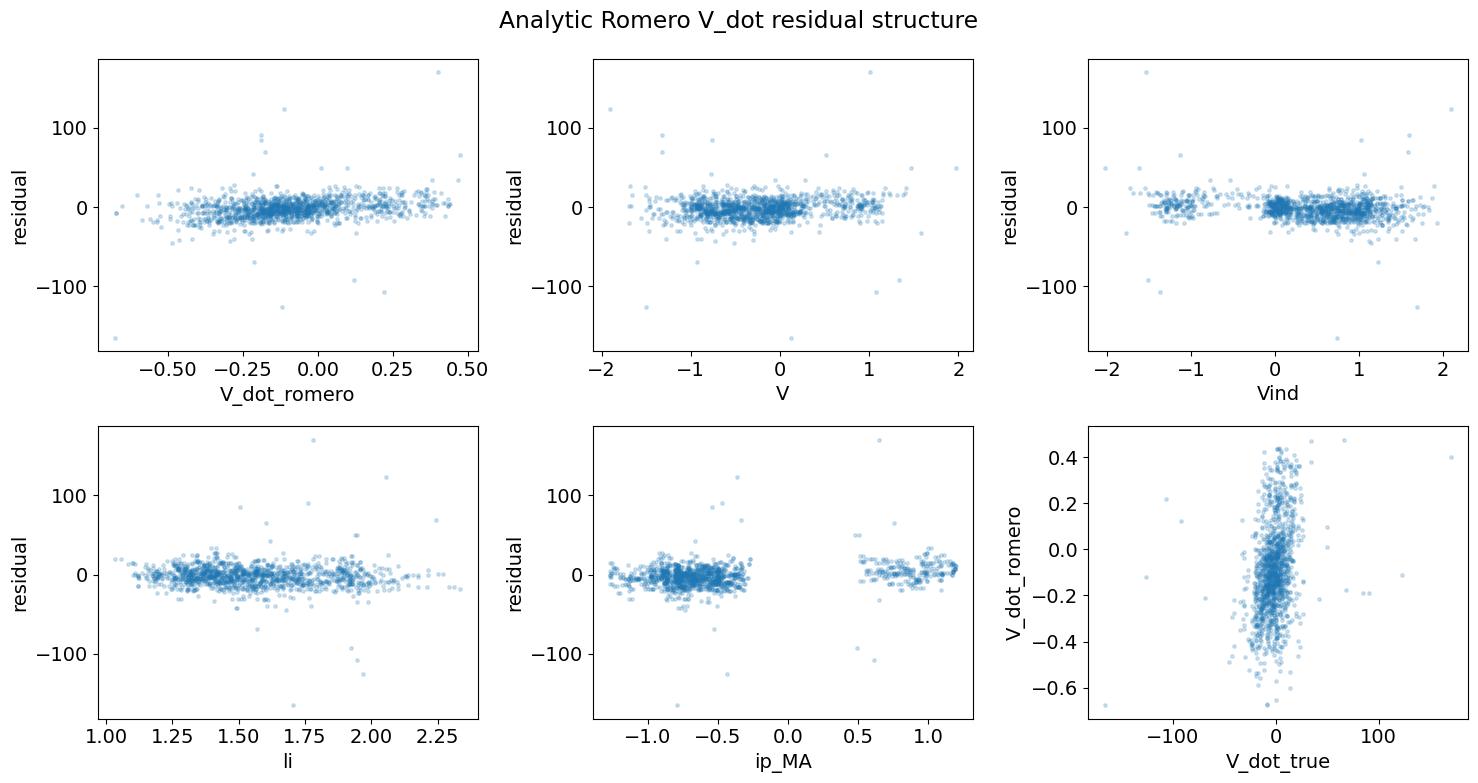

In [71]:
plot_residual_diagnostics(late_resid_df)

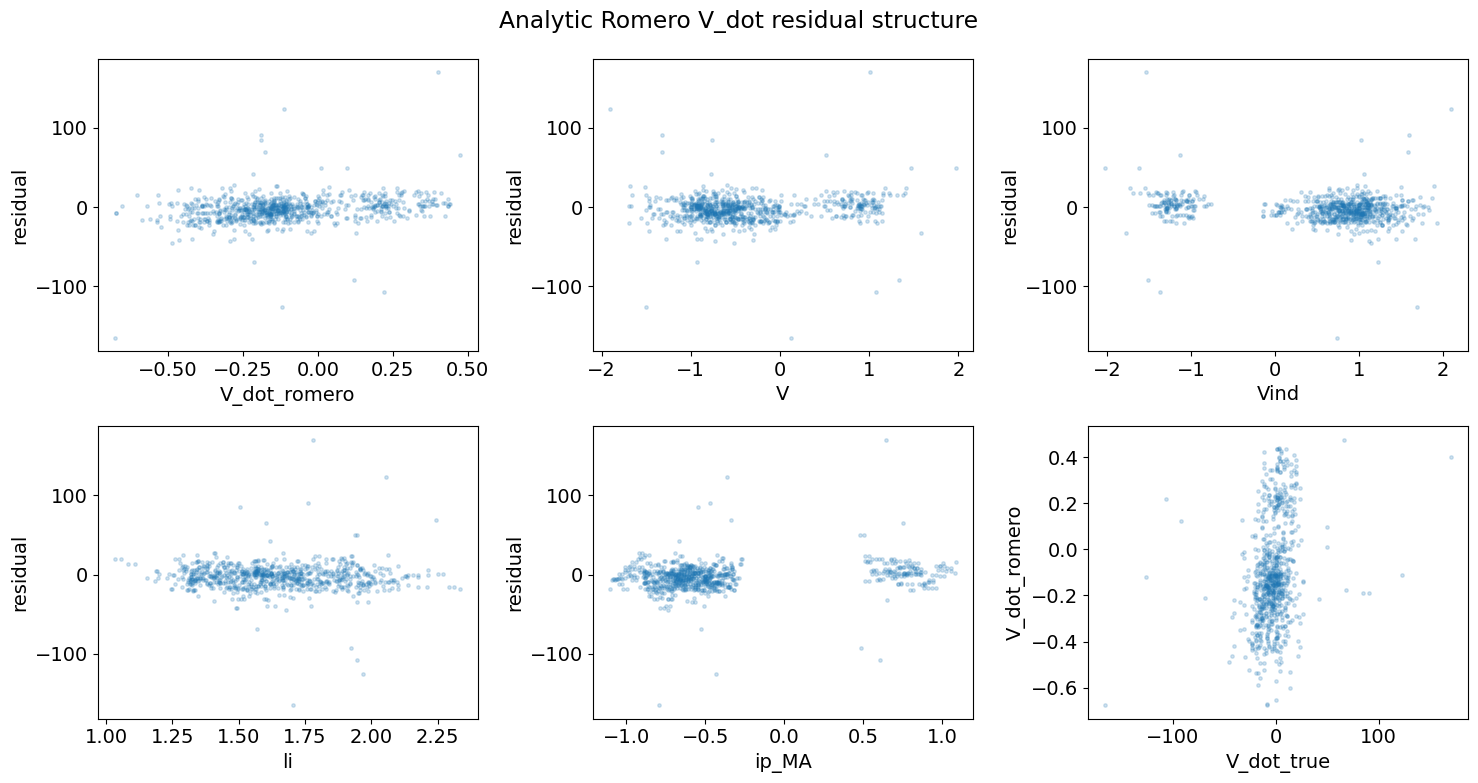

In [72]:
strict_late_resid_df = collect_late_residual_dataset(
    train_dfs,
    romero_model,
    dt_regular=0.01,
    tau_min=0.7,
    max_shots=50,
)

plot_residual_diagnostics(strict_late_resid_df)

In [73]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
import numpy as np

def build_sindy_library(df):
    li = df["li"].values
    ip = df["ip_MA"].values
    V = df["V"].values
    Vind = df["Vind"].values

    features = {
        "1": np.ones_like(V),
        "V": V,
        "Vind": Vind,
        "li": li,
        "ip": ip,
        "V^2": V**2,
        "Vind^2": Vind**2,
        "li^2": li**2,
        "ip^2": ip**2,
        "V*Vind": V * Vind,
        "li*V": li * V,
        "ip*V": ip * V,
        "li*Vind": li * Vind,
        "ip*Vind": ip * Vind,
    }

    names = list(features.keys())
    Theta = np.column_stack([features[k] for k in names])
    return Theta, names


def stlsq(Theta, y, threshold=0.05, alpha=1e-6, max_iter=10):
    scaler = StandardScaler()
    Theta_scaled = scaler.fit_transform(Theta)

    coef = Ridge(alpha=alpha, fit_intercept=False).fit(Theta_scaled, y).coef_

    for _ in range(max_iter):
        small = np.abs(coef) < threshold
        coef[small] = 0.0

        big = ~small
        if np.sum(big) == 0:
            break

        coef_big = Ridge(alpha=alpha, fit_intercept=False).fit(
            Theta_scaled[:, big],
            y
        ).coef_

        coef[:] = 0.0
        coef[big] = coef_big

    y_pred = Theta_scaled @ coef
    r2 = 1.0 - np.sum((y - y_pred)**2) / np.sum((y - np.mean(y))**2)

    return coef, r2


Theta, names = build_sindy_library(late_resid_df)
y = late_resid_df["residual"].values

coef, r2 = stlsq(Theta, y, threshold=0.05)

print("R2:", r2)
for name, c in zip(names, coef):
    if abs(c) > 0:
        print(name, c)

R2: 0.0914763784531174
V 20.38615147534169
Vind 28.370490103442314
li -5.983512237645048
ip 2.171987896379639
V^2 -3.130769672182996
Vind^2 3.3271298115465138
li^2 5.02237128131797
ip^2 0.6858024426417296
V*Vind -2.7455183458362873
li*V -33.51220779435376
li*Vind -42.30928011489202
ip*Vind 2.873872741061257


In [74]:
def endpoint_percent_errors_for_model(model, eps, name="Model"):
    li_errors = []
    ip_errors = []

    for init_state, controls, targets in eps:
        preds = model(init_state, controls)

        li_err = 100 * jnp.abs(preds["li"][-1] - targets["li"][-1]) / (
            jnp.abs(targets["li"][-1]) + 1e-8
        )

        ip_err = 100 * jnp.abs(preds["ip_MA"][-1] - targets["ip_MA"][-1]) / (
            jnp.abs(targets["ip_MA"][-1]) + 1e-8
        )

        li_errors.append(float(li_err))
        ip_errors.append(float(ip_err))

    print(f"{name} li mean ± std:", np.mean(li_errors), np.std(li_errors))
    print(f"{name} ip mean ± std:", np.mean(ip_errors), np.std(ip_errors))